In [2]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [3]:
# model = load_model("models/rice_disease_classifier.h5")
# print("Model loaded")
model = load_model("../models/rice_disease_classifier.h5")
print("Model loaded")




Model loaded


In [4]:
DATA_DIR = "../data/split"

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    os.path.join(DATA_DIR, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False   # ❗ rất quan trọng
)


Found 4317 images belonging to 9 classes.


In [5]:
loss, acc = model.evaluate(test_data)
print(f"Test accuracy: {acc:.4f}")



135/135 [==============================] - 59s 431ms/step - loss: 0.5804 - accuracy: 0.8575
Test accuracy: 0.8575


In [6]:
pred_probs = model.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes


135/135 [==============================] - 37s 267ms/step


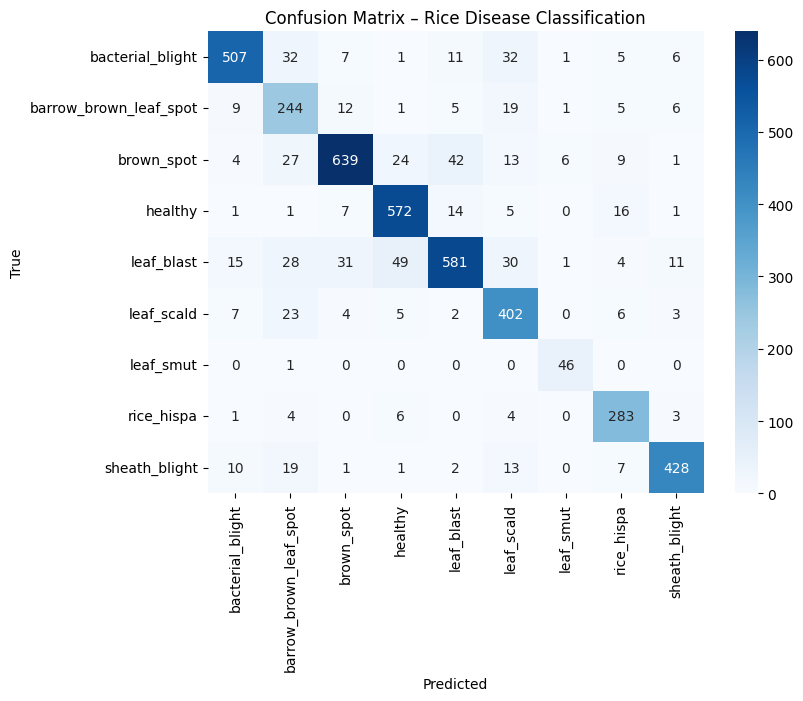

In [7]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_data.class_indices.keys(),
    yticklabels=test_data.class_indices.keys()
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Rice Disease Classification")
plt.show()


In [8]:
class_names = list(test_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                        precision    recall  f1-score   support

      bacterial_blight       0.92      0.84      0.88       602
barrow_brown_leaf_spot       0.64      0.81      0.72       302
            brown_spot       0.91      0.84      0.87       765
               healthy       0.87      0.93      0.90       617
            leaf_blast       0.88      0.77      0.83       750
            leaf_scald       0.78      0.89      0.83       452
             leaf_smut       0.84      0.98      0.90        47
            rice_hispa       0.84      0.94      0.89       301
         sheath_blight       0.93      0.89      0.91       481

              accuracy                           0.86      4317
             macro avg       0.85      0.88      0.86      4317
          weighted avg       0.87      0.86      0.86      4317



In [9]:
import random

errors = np.where(y_pred != y_true)[0]

print("Số ảnh dự đoán sai:", len(errors))


Số ảnh dự đoán sai: 615


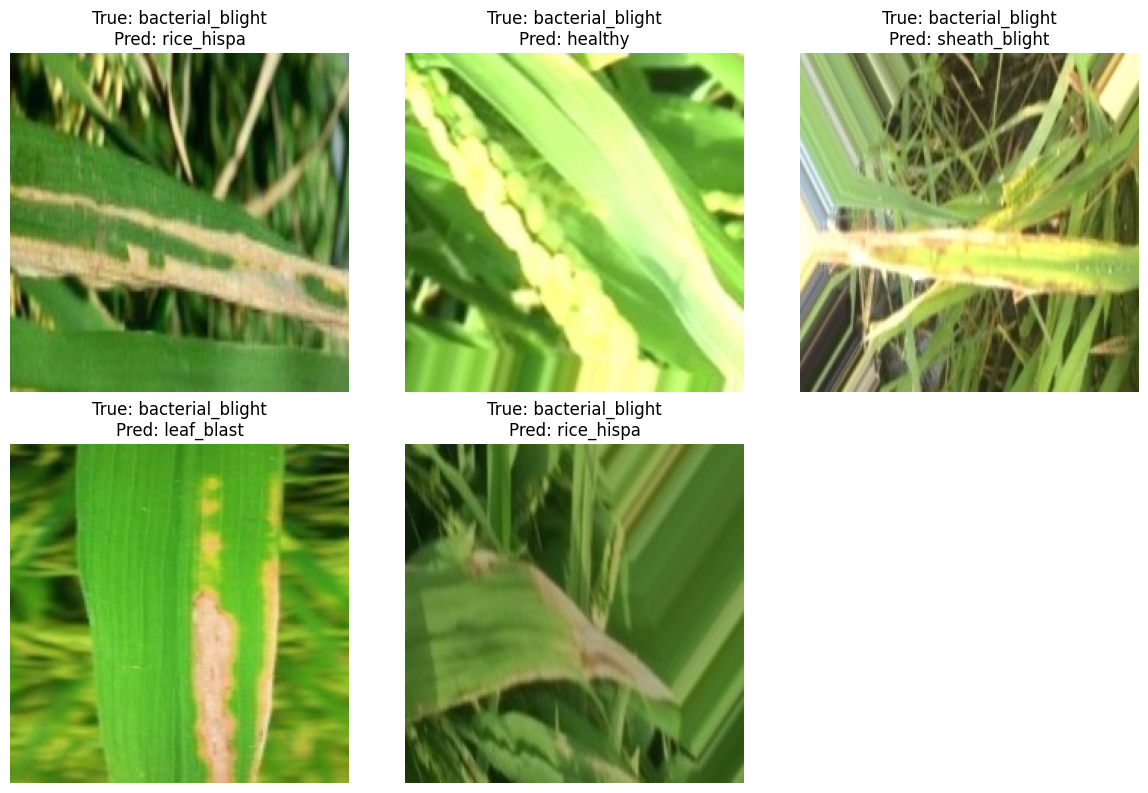

In [10]:
plt.figure(figsize=(12,8))

# for i, idx in enumerate(errors[:5]):
#     img, label = test_data[idx]
#     img = img[0]
#     true_label = class_names[y_true[idx]]
#     pred_label = class_names[y_pred[idx]]

#     plt.subplot(2,3,i+1)
#     plt.imshow(img)
#     plt.title(f"True: {true_label}\nPred: {pred_label}")
#     plt.axis("off")

batch_size = test_data.batch_size

for i, idx in enumerate(errors[:5]):
    batch_idx = idx // batch_size
    img_idx = idx % batch_size

    batch_imgs, batch_labels = test_data[batch_idx]
    img = batch_imgs[img_idx]
    label = batch_labels[img_idx]

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()
